In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import tensorflow as tf

from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.regularizers import L2


In [25]:
def encode_objects(df):
    for col, dtype in df.dtypes.items():
        if dtype == 'object':
            encoder = LabelEncoder()
            df[col] = encoder.fit_transform(df[col])
    return df

In [26]:
df_test = pd.read_csv("datasets/unsw-nb15/UNSW_NB15_testing-set.csv")
df_train = pd.read_csv("datasets/unsw-nb15/UNSW_NB15_training-set.csv")

In [27]:
# Keeping only the features selected in the paper A stacking... by Smitha Rajagopal

keep_cols = ['sbytes', 'sttl', 'sload', 'tcprtt', 'smean', 'ct_srv_src', 'ct_state_ttl', 'ct_src_dport_ltm', 'ct_dst_src_ltm', 'ct_srv_dst', 'service', 'label']

df_test = df_test[df_test.columns.intersection(keep_cols)]
df_train = df_train[df_train.columns.intersection(keep_cols)]

In [28]:
df_train['label'].value_counts()
df_test['label'].value_counts()

label
1    45332
0    37000
Name: count, dtype: int64

In [29]:
df_train_reduced = df_train.query('label == 0').sample(56000)

normal = df_test.query('label == 0').sample(37000)
attack = df_test.query('label == 1').sample(1000)
df_test_reduced = pd.concat([normal, attack]).sample(frac=1)

In [30]:
y_train = df_train_reduced['label']
x_train = df_train_reduced.drop("label", axis=1)

y_test = df_test_reduced['label']
x_test = df_test_reduced.drop("label", axis=1)

In [31]:
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

In [32]:
print(x_test.shape)
print(x_train.shape)

(38000, 11)
(44800, 11)


In [33]:
# encoding features which have data type as object and normalizing and normalizing numerical ones in specified interval

x_train = encode_objects(x_train)
x_val = encode_objects(x_val)
x_test = encode_objects(x_test)

In [34]:
scaler = StandardScaler()

scaler.fit(x_train)

x_train_transformed = scaler.transform(x_train)
x_val_transformed = scaler.transform(x_val)

## Tensorboard

In [35]:
# Load the extension and start TensorBoard
%load_ext tensorboard
%tensorboard --logdir logs/autoencoder_unsw/

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 20796), started 1 day, 15:58:57 ago. (Use '!kill 20796' to kill it.)

# Model

In [36]:
# data dimensions // hyperparameters 
input_dim = x_train_transformed.shape[1]
BATCH_SIZE = 64
EPOCHS = 100

# https://keras.io/layers/core/
autoencoder = tf.keras.models.Sequential([
    
    # deconstruct / encode
    tf.keras.layers.Input(shape=(input_dim,)), 
    tf.keras.layers.Dense(8, activation='relu', kernel_regularizer = L2(l2=1e-5)),
    tf.keras.layers.Dense(4, activation='relu', kernel_regularizer = L2(l2=1e-5)),
    tf.keras.layers.Dense(2, activation='relu', kernel_regularizer = L2(l2=1e-5)),
    
    # reconstruction / decode
    tf.keras.layers.Dense(4, activation='relu', kernel_regularizer = L2(l2=1e-5)),
    tf.keras.layers.Dense(8, activation='relu', kernel_regularizer = L2(l2=1e-5)),
    tf.keras.layers.Dense(input_dim, activation='relu', kernel_regularizer = L2(l2=1e-5))
    
])

# https://keras.io/api/models/model_training_apis/
autoencoder.compile(optimizer="adam", 
                    loss="mse",
                    metrics=["acc"])

# print an overview of our model
autoencoder.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 8)              │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 11)             │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 293 (1.14 KB)

 Trainable params: 293 (1.14 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
from datetime import datetime

# current date and time
yyyymmddHHMM = datetime.now().strftime('%Y%m%d%H%M')

# new folder for a new run
log_subdir = f'{yyyymmddHHMM}_batch{BATCH_SIZE}_layers{len(autoencoder.layers)}'

# define our early stopping
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0.0001,
    patience=10,
    verbose=1, 
    mode='min',
    restore_best_weights=True
)

save_model = tf.keras.callbacks.ModelCheckpoint(
    filepath='models/autoencoder_unsw_best_weights.keras', 
    save_best_only=True,
    monitor='val_loss',
    verbose=0,
    mode='min'
)

tensorboard = tf.keras.callbacks.TensorBoard(
    f'logs/autoencoder_unsw/{log_subdir}',
    update_freq='batch'
)

# callbacks argument only takes a list
cb = [early_stop, save_model, tensorboard]

In [38]:
history = autoencoder.fit(
    x_train_transformed, x_train_transformed,
    shuffle=True,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=cb,
    validation_data=(x_val_transformed, x_val_transformed)
)

Epoch 1/100


700/700 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - acc: 0.1675 - loss: 0.8475 - val_acc: 0.2920 - val_loss: 0.6443
Epoch 2/100
700/700 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.3123 - loss: 0.6476 - val_acc: 0.1862 - val_loss: 0.6097
Epoch 3/100
700/700 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.3272 - loss: 0.6391 - val_acc: 0.3421 - val_loss: 0.5986
Epoch 4/100
700/700 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.3487 - loss: 0.6316 - val_acc: 0.3404 - val_loss: 0.5919
Epoch 5/100
700/700 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.3498 - loss: 0.6264 - val_acc: 0.3525 - val_loss: 0.5883
Epoch 6/100
700/700 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.3553 - loss: 0.6290 - val_acc: 0.3564 - val_loss: 0.5850
Epoch 7/100
700/700 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.3602 - loss: 0.6046 - val_acc: 0.3663 - val_loss: 0.5807
Epoch 8/100
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.3640 - loss: 0.6125 - val_acc: 0.3715 - val_loss: 0.5758
Epoch 9/100
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 

In [39]:
x_test_transformed = scaler.transform(x_test)

reconstructions = autoencoder.predict(x_test_transformed)

1188/1188 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [56]:
mse = np.mean(np.power(x_test_transformed - reconstructions, 2), axis=1)
mse.shape

(38000,)

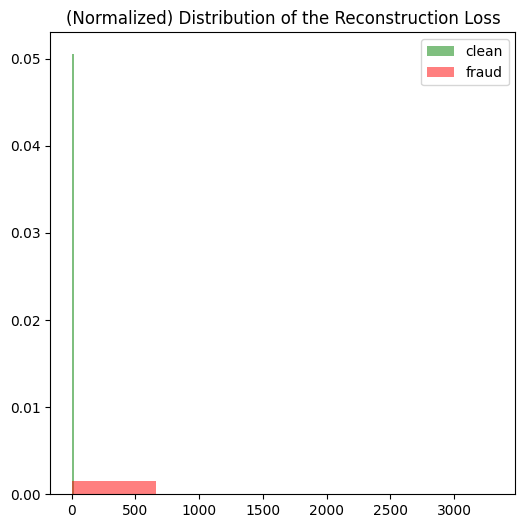

In [41]:
clean = mse[y_test==0]
fraud = mse[y_test==1]

fig, ax = plt.subplots(figsize=(6,6))

ax.hist(clean, bins=5, density=True, label="clean", alpha=.5, color="green")
ax.hist(fraud, bins=5, density=True, label="fraud", alpha=.5, color="red")

plt.title("(Normalized) Distribution of the Reconstruction Loss")
plt.legend()
plt.show()

In [42]:
def mad_score(points):
    """https://www.itl.nist.gov/div898/handbook/eda/section3/eda35h.htm """
    m = np.median(points)
    ad = np.abs(points - m)
    mad = np.median(ad)
    
    return 0.6745 * ad / mad

In [52]:
THRESHOLD = 1.5

z_scores = mad_score(mse)
outliers = z_scores > THRESHOLD


F1 Score: 0.07480769230769231
Precision: 0.041382978723404254
Recall: 0.389
Accuracy: 0.7467894736842106


Text(50.722222222222214, 0.5, 'True Label')

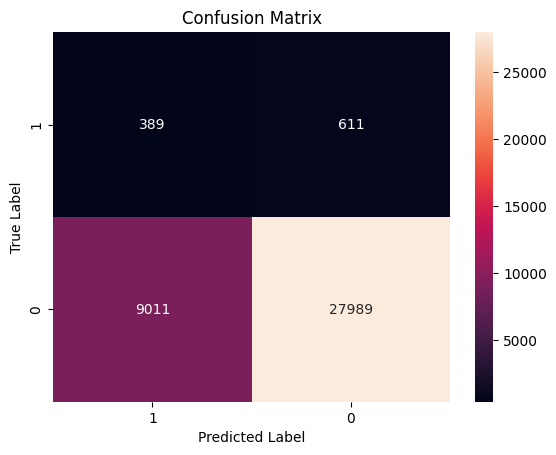

In [53]:
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, accuracy_score

f1_test = f1_score(y_test, outliers)
precision_test = precision_score(y_test, outliers)
recall_test = recall_score(y_test, outliers)
accuracy_test = accuracy_score(y_test, outliers)

print(f"F1 Score: {f1_test}\nPrecision: {precision_test}\nRecall: {recall_test}\nAccuracy: {accuracy_test}")

cm = confusion_matrix(y_test, outliers)
plt.title("Confusion Matrix")
ax = sns.heatmap(cm, annot=True, fmt='0.0f')
ax.invert_yaxis()
ax.invert_xaxis()
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')

In [54]:
tn, fp, fn, tp = cm.ravel()
print("tp:", tp, "fp:", fp, "tn:", tn, "fn:", fn)
print("False Negative Rate:", fn/(fn+tn))
print("False Positive Rate:", fp/(fp+tp))

tp: 389 fp: 9011 tn: 27989 fn: 611
False Negative Rate: 0.021363636363636362
False Positive Rate: 0.9586170212765958
